In [1]:
#prepare dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix
)

In [2]:
#create boold donor datset
data = {
    "Age":[20,22,24,25,27,28,30,31,33,35,36,38,40,42,45,23,26,29,32,37],
    "Donations":[1,2,2,3,3,4,4,5,5,6,6,7,8,8,9,2,3,4,5,7],
    "Weight":[50,55,60,62,65,68,70,72,75,78,80,82,85,88,90,58,64,69,74,81],
    "Units_Donated":[1,2,2,3,3,4,4,5,5,6,6,7,8,8,9,2,3,4,5,7],
    "Available":[1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1,0,0]
}

df = pd.DataFrame(data)

df.head()

,Age,Donations,Weight,Units_Donated,Available
0,20,1,50,1,1
1,22,2,55,2,1
2,24,2,60,2,1
3,25,3,62,3,1
4,27,3,65,3,1


In [3]:
#regression
#prepare data
X = df[["Age"]]
y = df["Units_Donated"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
#linear regression model
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: 0.978930703623932
Mean Squared Error: 0.02501978944658079


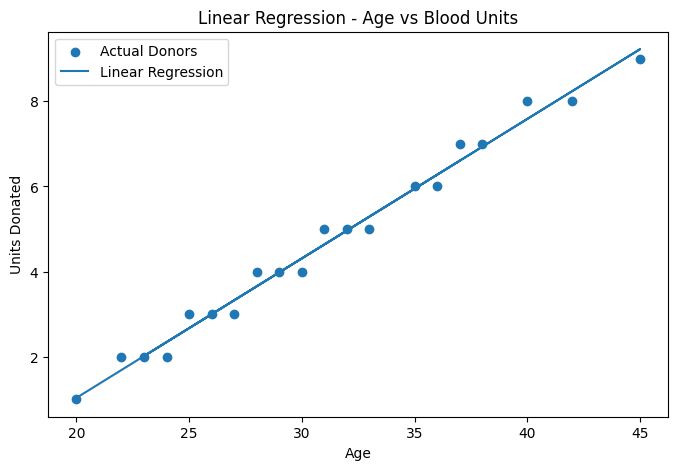

In [5]:
#linear regression graph
plt.figure(figsize=(8,5))

plt.scatter(X, y, label="Actual Donors")

plt.plot(
    X,
    linear_model.predict(X),
    label="Linear Regression"
)

plt.xlabel("Age")
plt.ylabel("Units Donated")
plt.title("Linear Regression - Age vs Blood Units")

plt.legend()
plt.show()

In [6]:
#polynomial regression
poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X_train, y_train)

poly_pred = poly_model.predict(X_test)

print("R2 Score:", r2_score(y_test, poly_pred))
print("Mean Squared Error:", mean_squared_error(y_test, poly_pred))

R2 Score: 0.9355102347746314
Mean Squared Error: 0.0765815962051253


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


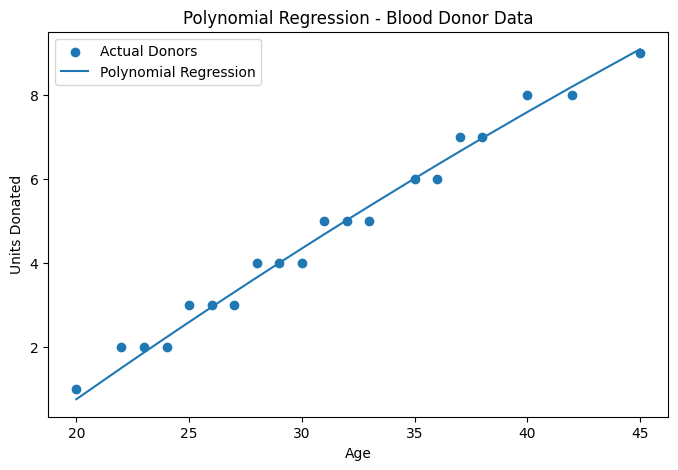

In [7]:
#polynomial regression graph
X_sorted = np.sort(X.values, axis=0)

poly_predictions = poly_model.predict(X_sorted)

plt.figure(figsize=(8,5))

plt.scatter(X, y, label="Actual Donors")

plt.plot(
    X_sorted,
    poly_predictions,
    label="Polynomial Regression"
)

plt.xlabel("Age")
plt.ylabel("Units Donated")
plt.title("Polynomial Regression - Blood Donor Data")

plt.legend()
plt.show()

In [8]:
#ridge regression
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

print("R2 Score:", r2_score(y_test, ridge_pred))
print("Mean Squared Error:", mean_squared_error(y_test, ridge_pred))

R2 Score: 0.9796009722338862
Mean Squared Error: 0.02422384547226012


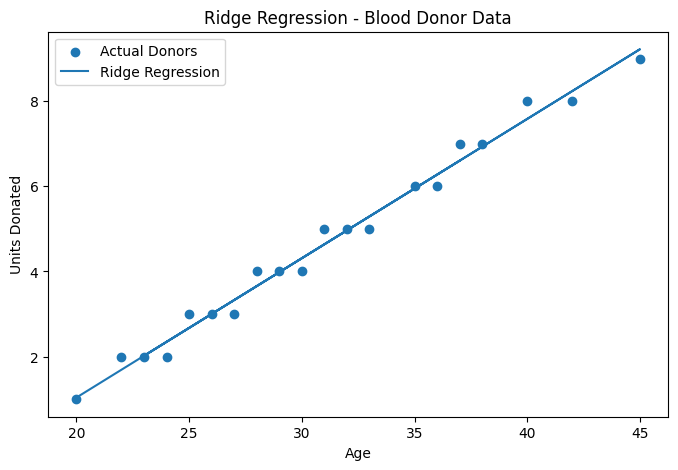

In [9]:
#ridge regression graph
plt.figure(figsize=(8,5))

plt.scatter(X, y, label="Actual Donors")

plt.plot(
    X,
    ridge_model.predict(X),
    label="Ridge Regression"
)

plt.xlabel("Age")
plt.ylabel("Units Donated")
plt.title("Ridge Regression - Blood Donor Data")

plt.legend()
plt.show()

In [10]:
#lasso regression
lasso_model = Lasso(alpha=0.01)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

print("R2 Score:", r2_score(y_test, lasso_pred))
print("Mean Squared Error:", mean_squared_error(y_test, lasso_pred))

R2 Score: 0.9792648874594609
Mean Squared Error: 0.02462294614189016


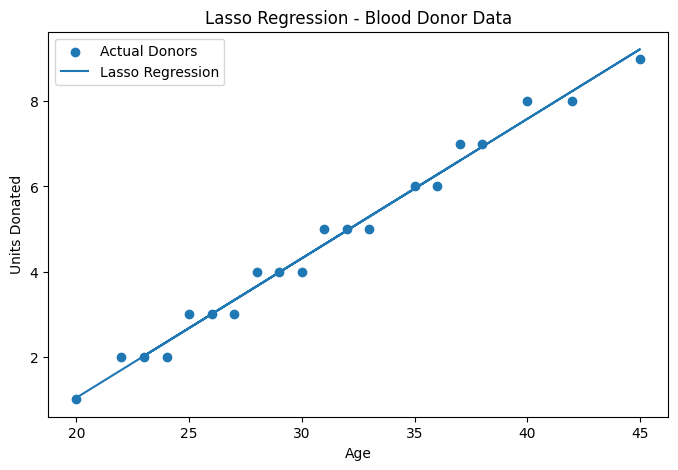

In [11]:
#lasso regression graph
plt.figure(figsize=(8,5))

plt.scatter(X, y, label="Actual Donors")

plt.plot(
    X,
    lasso_model.predict(X),
    label="Lasso Regression"
)

plt.xlabel("Age")
plt.ylabel("Units Donated")
plt.title("Lasso Regression - Blood Donor Data")

plt.legend()
plt.show()

In [12]:
#logistic regression
X = df[["Age", "Donations", "Weight"]]
y = df["Available"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
#logistic regression model
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, logistic_pred))

Accuracy: 1.0


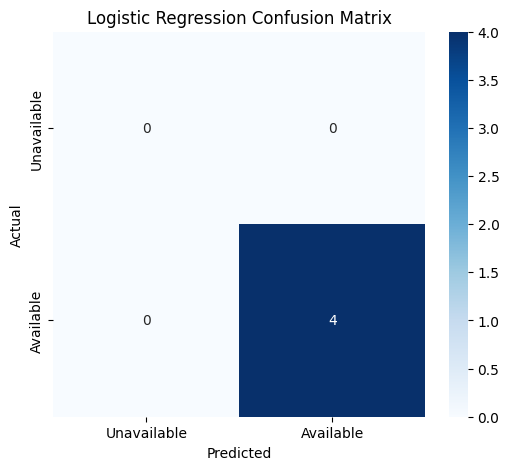

In [15]:
#logistic regression confusion matrix
cm = confusion_matrix(y_test, logistic_pred, labels=[0, 1])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unavailable", "Available"],
    yticklabels=["Unavailable", "Available"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [16]:
#KNN classification
knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=3)
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

KNN Accuracy: 1.0


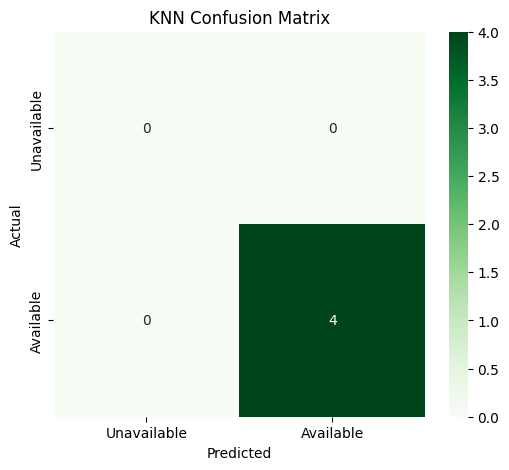

In [18]:
#KNN confusion matrix
knn_cm = confusion_matrix(y_test, knn_pred, labels=[0, 1])

plt.figure(figsize=(6,5))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Unavailable", "Available"],
    yticklabels=["Unavailable", "Available"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [19]:
#compare all models
models = [
    "Linear Regression",
    "Polynomial Regression",
    "Ridge Regression",
    "Lasso Regression",
    "Logistic Regression",
    "KNN"
]

scores = [
    r2_score(y_test, linear_model.predict(X_test[["Age"]])),
    r2_score(y_test, poly_model.predict(X_test[["Age"]])),
    r2_score(y_test, ridge_model.predict(X_test[["Age"]])),
    r2_score(y_test, lasso_model.predict(X_test[["Age"]])),
    accuracy_score(y_test, logistic_pred),
    accuracy_score(y_test, knn_pred)
]

print("Model Performance")

for model, score in zip(models, scores):
    print(model, ":", round(score, 3))

Model Performance
Linear Regression : 0.0
Polynomial Regression : 0.0
Ridge Regression : 0.0
Lasso Regression : 0.0
Logistic Regression : 1.0
KNN : 1.0
